Defining the percentage of oil that goes below the surface layer in the Haro Boundary region, for use in Atlantis dilbit spills. Based on original notebook from Susan Allen as part of the MIDOSS project.

In [1]:
import copy
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import geopandas as gpd
import numpy as np
import xarray as xr
from shapely.affinity import rotate

%matplotlib inline

In [2]:
haro_boundary = [60,33]

In [3]:
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
data_df_original = data_df_original.sort_values(by=['BOX_ID'])
data_df = data_df_original.set_index('BOX_ID')
box_depth = data_df['BOTZ']
land_boxes = box_depth==0

In [4]:
map_angle = -37

geom = data_df.unary_union
centroid = geom.centroid
ssam_rotated = data_df.copy()
ssam_rotated["geometry"] = data_df.geometry.apply(
    lambda g: rotate(g, map_angle, origin=geom.centroid)
    
)

In [5]:
land_boxes = ssam_rotated.index[land_boxes]
land_df = ssam_rotated.loc[land_boxes]
haro_df = ssam_rotated.loc[haro_boundary]

In [6]:
thefile = '/data/sallen/MIDOSS/aggregated_spills_files/fiftieth_55_oils.nc'
oil = xr.open_dataset(thefile)
whichspills = "All Oil Spills"
smalloils = 113 + 54

In [7]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask201702.nc')
tmask = 1- mesh.tmask[0, 0]
divarea = 1/(mesh.e1t[0, 1:-1, 1:-1] * mesh.e2t[0, 1:-1, 1:-1])
alength = 1/np.maximum(mesh.e1t[0, 1:-1:, 1:-1], mesh.e2t[0, 1:-1, 1:-1])
mesh.close()

In [8]:
eps = 1e-7
need = 4   # need four values at a point to calculate quartiles

In [9]:
ma_deep_pres = np.ma.masked_array(oil.deeppresence, oil.deeppresence == 0)
ma_deep_location = np.ma.masked_array(oil.deep_location[0]/(oil.deeppresence + eps), 
                                      oil.deeppresence == 0)
location = np.ma.masked_array(oil.deep_location[0]/(oil.deeppresence + eps), 
                              (oil.deeppresence < need))

In [10]:
absol = 5
perol = 0.25

wd_absol = absol
wd_perol = perol

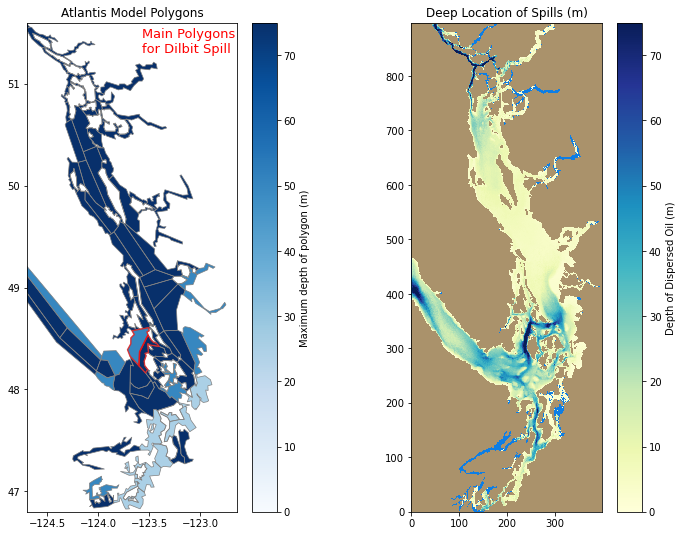

In [11]:
# Atlantis Location Map with SalishSeaCast Box Location
aspect = 500/440

fig, axs = plt.subplots(1, 2, figsize=(12, 9)) 

#divider = make_axes_locatable(axs[0])
#cax = divider.append_axes("right", size="5%", pad= -0.5) 
axs[0] = ssam_rotated.plot(column = 'BOTZ', ax=axs[0], cmap=cm.Blues, vmax = 75, #cax=cax,
    legend=True, legend_kwds={'label': 'Maximum depth of polygon (m)'
    },)
ssam_rotated.boundary.plot(ax=axs[0], color='grey', linewidths=0.7)
haro_df.boundary.plot(ax=axs[0], color='red',  alpha=0.6, linewidths=1.5, label='matching Atlantis polygons')
land_df.plot(ax=axs[0], color='white')
axs[0].text(0.55, 0.94, 'Main Polygons\nfor Dilbit Spill',transform=axs[0].transAxes, color='red', fontsize=13)
#axs[0].text(0.05, 0.95, '(a)', transform=axs[0].transAxes, color='black', fontsize=14,) #fontweight='bold'
axs[0].set_aspect("equal")
axs[0].set_ylim(46.8, 51.6)
axs[0].set_xlim(-124.7)
axs[0].set_title('Atlantis Model Polygons');    

axs[1].pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
axs[1].set_ylim(0, 898)
axs[1].set_xlim(0, 398)
axs[1].set_aspect(aspect)
#axs[1].text(2.05, 0.95, '(b)', transform=axs[0].transAxes, color='black', fontsize=14, zorder=4) #fontweight='bold'

C = axs[1].pcolormesh(
     ma_deep_location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[1]);
cb.set_label('Depth of Dispersed Oil (m)')    
axs[1].set_title('Deep Location of Spills (m)');    

In [12]:
# Refined for Haro Boundary Region
imin = 200
jmin, jmax = 150, 350
#imax = imin + (jmax - jmin)*2/500*440
imax = 500

In [13]:
oil.data_vars

Data variables:
    beaching_time    (c, grid_y, grid_x) float64 ...
    beachpresence    (grid_y, grid_x) float64 ...
    beaching_oil     (c, grid_y, grid_x) float64 ...
    oiling_time      (c, grid_y, grid_x) float64 ...
    oilpresence      (grid_y, grid_x) float64 ...
    surface_oil      (c, grid_y, grid_x) float64 ...
    deeppresence     (grid_y, grid_x) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    deep_oil         (c, grid_y, grid_x) float64 ...
    deep_location    (c, grid_y, grid_x) float64 ...
    files_aggregate  (nf) object ...
    nofiles          int64 ...

### Surface oil

In [14]:
ma_oil_pres = np.ma.masked_array(oil.oilpresence, oil.oilpresence == 0)

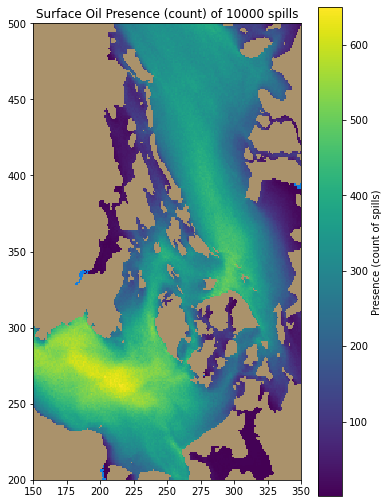

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(6, 9))

ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
ax.set_ylim(imin, imax)
ax.set_xlim(jmin, jmax)
ax.set_aspect(aspect)


C = ax.pcolormesh(ma_oil_pres, zorder=2,)# cmap='gist_ncar')
cb = fig.colorbar(C, ax=ax);    
cb.set_label('Presence (count of spills)')
ax.set_title(f'Surface Oil Presence (count) of {oil.nofiles.values+smalloils} spills');   

Surface oil volume

In [16]:
absol = 0.5
perol = 0.25
mcsize = 49

bt_absol = absol
bt_perol = perol

In [17]:
ma_surface_oil = np.ma.masked_array(oil.surface_oil[0]/(oil.oilpresence + eps), 
                                    oil.oilpresence == 0)

surfoil_25 = np.quantile(oil.surface_oil/(oil.oilpresence + eps), 0.25, axis=0)
surfoil_75 = np.quantile(oil.surface_oil/(oil.oilpresence + eps), 0.75, axis=0)

surfoiled = np.ma.masked_array(oil.surface_oil[0]/(oil.oilpresence + eps), 
                               (oil.oilpresence < need) | (
    (np.exp(surfoil_75) - np.exp(surfoil_25) > np.exp(ma_surface_oil)) )) 

ma_surfoil_del = np.ma.masked_array(np.exp(surfoil_75) - 
                                    np.exp(surfoil_25), oil.oilpresence < need)

print (ma_surface_oil.max(), surfoil_75.max())

7.129695074040375 14.055608038963308


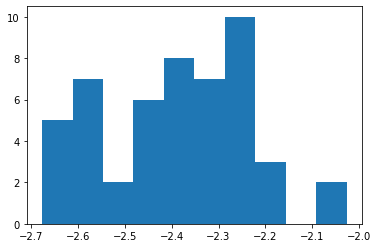

In [18]:
plt.hist(oil.surface_oil[:, 400, 300]/(oil.oilpresence[400, 300] + eps));

### Deep oil

In [19]:
	
ma_deep_location = np.ma.masked_array(oil.deep_location[0]/(oil.deeppresence + eps), 
                                      oil.deeppresence == 0)
print (oil.deep_location.shape)
location_25 = np.quantile(oil.deep_location/(oil.deeppresence + eps), 0.25, axis=0)
location_75 = np.quantile(oil.deep_location/(oil.deeppresence + eps), 0.75, axis=0)
print (location_25.shape)

location = np.ma.masked_array(oil.deep_location[0]/(oil.deeppresence + eps), 
                              (oil.deeppresence < need) | (
    (location_75 - location_25 > absol) 
    & (location_75 - location_25 > perol*ma_deep_location))) 

ma_location_del = np.ma.masked_array(location_75 - location_25, oil.deeppresence < need)

print (ma_deep_location.max())

(50, 896, 396)
(896, 396)
279.9262886394291


55.88931975981047 <xarray.DataArray 'deeppresence' ()>
array(378.)
Coordinates:
    grid_x   int64 300
    grid_y   int64 350
    grid_z   int16 ...


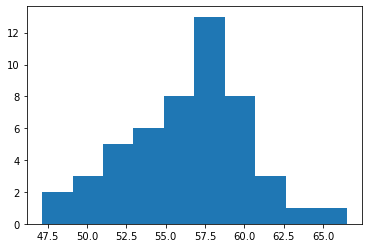

In [20]:
plt.hist(oil.deep_location[:, 350, 300]/oil.deeppresence[350, 300]);
print (ma_deep_location[350, 300], oil.deeppresence[350, 300])

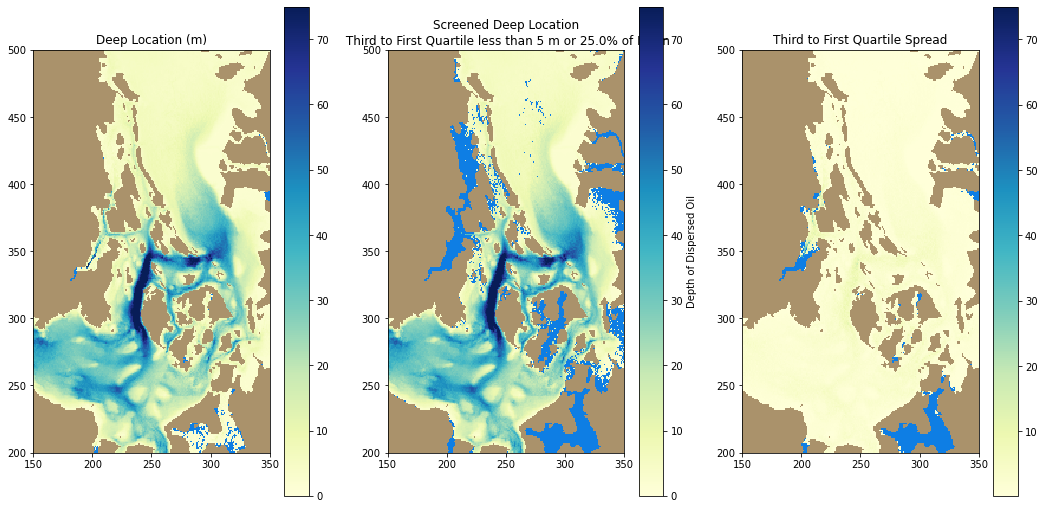

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(18, 9))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=-0.95) 

for ax in axs:
    ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
    ax.set_ylim(imin, imax)
    ax.set_xlim(jmin, jmax)
    ax.set_aspect(aspect)

C = axs[0].pcolormesh(
     ma_deep_location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[0]);    
axs[0].set_title('Deep Location (m)');    

C = axs[1].pcolormesh(
     location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[1]);
cb.set_label('Depth of Dispersed Oil')
axs[1].set_title(
    f'Screened Deep Location\n Third to First Quartile less than {wd_absol} m or {wd_perol*100}% of Mean')

C = axs[2].pcolormesh(ma_location_del, 
    zorder=2, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[2]);
axs[2].set_title('Third to First Quartile Spread');

Deep oil volume

In [22]:
ma_deep_oil = np.ma.masked_array(oil.deep_oil[0]/(oil.deeppresence + eps), 
                                 oil.deeppresence == 0)

deepoil_25 = np.quantile(oil.deep_oil/(oil.deeppresence + eps), 0.25, axis=0)
deepoil_75 = np.quantile(oil.deep_oil/(oil.deeppresence + eps), 0.75, axis=0)

deepoiled = np.ma.masked_array(oil.deep_oil[0]/(oil.deeppresence + eps), 
                               (oil.deeppresence < need) | (
    (np.exp(deepoil_75) - np.exp(deepoil_25) > np.exp(ma_deep_oil)) )) 

ma_deepoil_ste = np.ma.masked_array(np.exp(deepoil_75) 
                                    - np.exp(deepoil_25), oil.deeppresence < need)

### Comparison

In [23]:
all_oil_presence = oil.deeppresence + oil.oilpresence

In [24]:
all_oil_presence.dims

('grid_y', 'grid_x')

In [25]:
percent_deeppresence = oil.deeppresence / all_oil_presence

In [26]:
percent_surface_presence = oil.oilpresence / all_oil_presence

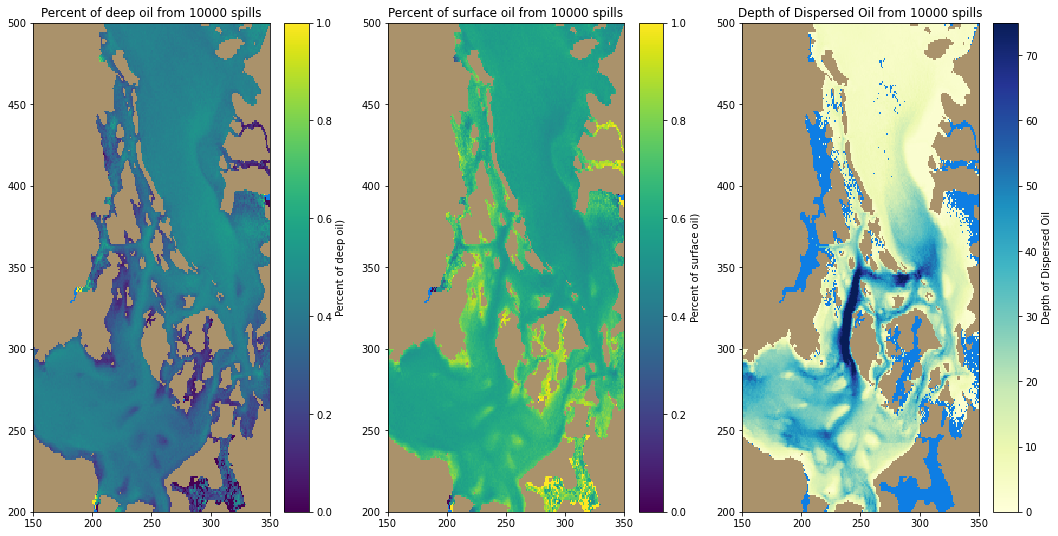

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(18, 9))

for ax in axs:
    ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
    ax.set_ylim(imin, imax)
    ax.set_xlim(jmin, jmax)

C = axs[0].pcolormesh(percent_deeppresence, zorder=2)# cmap='gist_ncar')
cb = fig.colorbar(C, ax=axs[0]);    
cb.set_label('Percent of deep oil)')
axs[0].set_title(f'Percent of deep oil from {oil.nofiles.values+smalloils} spills');   

C = axs[1].pcolormesh(percent_surface_presence, zorder=2)# cmap='gist_ncar')
cb = fig.colorbar(C, ax=axs[1]);    
cb.set_label('Percent of surface oil)')
axs[1].set_title(f'Percent of surface oil from {oil.nofiles.values+smalloils} spills');  

C = axs[2].pcolormesh(
     location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[2]);
cb.set_label('Depth of Dispersed Oil')
axs[2].set_title(
    f'Depth of Dispersed Oil from {oil.nofiles.values+smalloils} spills');

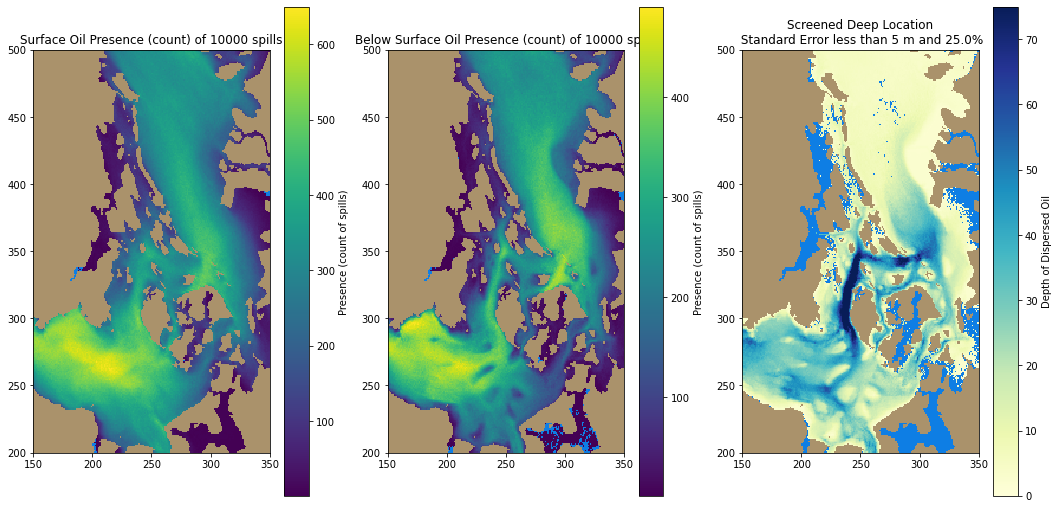

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(18, 9))

for ax in axs:
    ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
    ax.set_ylim(imin, imax)
    ax.set_xlim(jmin, jmax)
    ax.set_aspect(aspect)
        
C = axs[0].pcolormesh(ma_oil_pres, zorder=2)
cb = fig.colorbar(C, ax=axs[0]);    
cb.set_label('Presence (count of spills)')
axs[0].set_title(
    f'Surface Oil Presence (count) of {oil.nofiles.values+smalloils} spills');  

C = axs[1].pcolormesh(ma_deep_pres, zorder=2)
cb = fig.colorbar(C, ax=axs[1]);    
cb.set_label('Presence (count of spills)')
axs[1].set_title(
    f'Below Surface Oil Presence (count) of {oil.nofiles.values+smalloils} spills');   

C = axs[2].pcolormesh(
     location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[2]);
cb.set_label('Depth of Dispersed Oil')
axs[2].set_title(
    f'Screened Deep Location\n Standard Error less than {wd_absol} m and {wd_perol*100}%');

In [29]:
spill_depths = np.ma.masked_array(oil.deep_location[0,200:500,150:350]/(oil.deeppresence[200:500,150:350] + eps))

In [30]:
depth_bins = [0, 25, 50, 100]

In [31]:
counts, edges = np.histogram(spill_depths, bins=depth_bins)

In [32]:
percentages = counts / counts.sum() * 100

In [33]:
for i in range(len(counts)):
    print(f"{edges[i]}–{edges[i+1]} m: {percentages[i]:.1f}%")

0–25 m: 83.7%
25–50 m: 14.3%
50–100 m: 1.9%


Text(0, 0.5, 'Depth (m)')

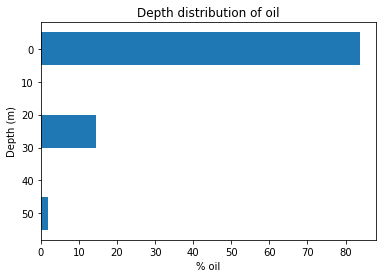

In [34]:
plt.barh(edges[0:3],percentages, height=10, align='center')
plt.gca().invert_yaxis() 
plt.title('Depth distribution of oil')
plt.xlabel('% oil')
plt.ylabel('Depth (m)')
